In [65]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [67]:
whisky = pd.read_csv('thebourbonguidecom.csv', delimiter=',')

In [91]:
whisky

Score                       85
Bottle                     NaN
Proof                        0
Reviewer                 Jason
Nose                  Pleasant
LeatherDesc    Noticeable (-4)
SweetDesc            Faint (2)
Date                01/01/1970
Name: 150, dtype: object

In [4]:
whisky['Date'].value_counts()

Date
01/01/1970    223
18/06/2025      1
Name: count, dtype: int64

In [5]:
whisky = whisky.drop('Date', axis=1)

In [6]:
whisky.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Score        224 non-null    int64 
 1   Bottle       221 non-null    object
 2   Proof        224 non-null    int64 
 3   Reviewer     224 non-null    object
 4   Nose         224 non-null    object
 5   LeatherDesc  224 non-null    object
 6   SweetDesc    224 non-null    object
dtypes: int64(2), object(5)
memory usage: 12.4+ KB


In [7]:
whisky['Leather'] = whisky['LeatherDesc'].str.extract(pat='([0-9])')

In [8]:
whisky['Sweetness'] = whisky['SweetDesc'].str.extract(pat='([0-9])')

In [9]:
whisky.head()

,Score,Bottle,Proof,Reviewer,Nose,LeatherDesc,SweetDesc,Leather,Sweetness
0,59,Four Roses Single Barrel (Barrel GW-5K),100,Tony,Unpleasant,Neutral (0),Somewhat (3),0,3
1,65,Leopold Bros,86,Tripp,Unpleasant,Full (-6),Neutral (0),6,0
2,65,Few Rye (Bottle 8),93,Chad,Unpleasant,Adequate (-5),Neutral (0),5,0
3,65,Old Fitzgerald 101,101,Tripp,Pleasant,Neutral (0),Neutral (0),0,0
4,70,Four Roses Single Barrel (Barrel GW-5K),100,Tripp,Pleasant,Somewhat (-3),Neutral (0),3,0


In [10]:
whisky = whisky.reset_index()
whisky2 = whisky.copy()
whisky.head()

,index,Score,Bottle,Proof,Reviewer,Nose,LeatherDesc,SweetDesc,Leather,Sweetness
0,0,59,Four Roses Single Barrel (Barrel GW-5K),100,Tony,Unpleasant,Neutral (0),Somewhat (3),0,3
1,1,65,Leopold Bros,86,Tripp,Unpleasant,Full (-6),Neutral (0),6,0
2,2,65,Few Rye (Bottle 8),93,Chad,Unpleasant,Adequate (-5),Neutral (0),5,0
3,3,65,Old Fitzgerald 101,101,Tripp,Pleasant,Neutral (0),Neutral (0),0,0
4,4,70,Four Roses Single Barrel (Barrel GW-5K),100,Tripp,Pleasant,Somewhat (-3),Neutral (0),3,0


In [11]:
whisky.loc[[2]]

,index,Score,Bottle,Proof,Reviewer,Nose,LeatherDesc,SweetDesc,Leather,Sweetness
2,2,65,Few Rye (Bottle 8),93,Chad,Unpleasant,Adequate (-5),Neutral (0),5,0


In [12]:
# Convert categorical data to numerical data using cat.codes
whisky['Nose_cat'] = whisky['Nose'].astype('category')
whisky['Nose_cat'] = whisky['Nose_cat'].cat.codes
whisky.head()

,index,Score,Bottle,Proof,Reviewer,Nose,LeatherDesc,SweetDesc,Leather,Sweetness,Nose_cat
0,0,59,Four Roses Single Barrel (Barrel GW-5K),100,Tony,Unpleasant,Neutral (0),Somewhat (3),0,3,2
1,1,65,Leopold Bros,86,Tripp,Unpleasant,Full (-6),Neutral (0),6,0,2
2,2,65,Few Rye (Bottle 8),93,Chad,Unpleasant,Adequate (-5),Neutral (0),5,0,2
3,3,65,Old Fitzgerald 101,101,Tripp,Pleasant,Neutral (0),Neutral (0),0,0,1
4,4,70,Four Roses Single Barrel (Barrel GW-5K),100,Tripp,Pleasant,Somewhat (-3),Neutral (0),3,0,1


----------------------

In [14]:
whisky2 = whisky.copy()
whisky = whisky.drop(columns=['Bottle','Reviewer', 'Nose', 'LeatherDesc', 'SweetDesc'])
whisky.head(10)

,index,Score,Proof,Leather,Sweetness,Nose_cat
0,0,59,100,0,3,2
1,1,65,86,6,0,2
2,2,65,93,5,0,2
3,3,65,101,0,0,1
4,4,70,100,3,0,1
5,5,70,100,0,1,0
6,6,70,86,3,0,2
7,7,70,94,2,0,2
8,8,71,90,6,0,0
9,9,71,101,3,0,1


In [15]:
scaled = StandardScaler().fit_transform(whisky)
print(scaled)

[[-1.72433562 -3.60743033  0.40199234 -0.75447765  0.80726593  1.60101723]
 [-1.70887073 -2.69401918 -0.5465765   2.49557992 -1.03791334  1.60101723]
 [-1.69340583 -2.69401918 -0.07229208  1.95390366 -1.03791334  1.60101723]
 ...
 [ 1.69340583  1.87303654  1.68933577 -0.75447765  1.42232568  0.23220861]
 [ 1.70887073  1.87303654  0.06321776  0.87055114  1.42232568  1.60101723]
 [ 1.72433562  2.02527174  1.68933577 -0.21280139  0.80726593  0.23220861]]


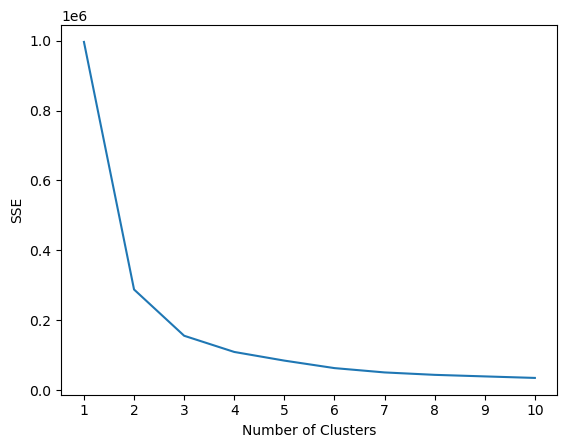

In [16]:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(whisky)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [17]:
#instantiate the k-means class, using optimal number of clusters
kmeans = KMeans(init="random", n_clusters=5, n_init=10, random_state=1)

#fit k-means algorithm to data
kmeans.fit(scaled)

#view cluster assignments for each observation
kmeans.labels_

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 1, 2, 0,
       2, 2, 0, 1, 2, 1, 1, 1, 1, 2, 0, 0, 1, 2, 1, 1, 2, 1, 0, 0, 0, 1,
       1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 0, 1, 0, 2, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 0, 2, 2,
       0, 1, 1, 1, 0, 1, 4, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 4, 4, 4, 1, 4, 0, 0, 0, 4,
       0, 4, 4, 1, 1, 1, 1, 1, 1, 4, 0, 0, 4, 0, 0, 0, 4, 3, 3, 4, 4, 0,
       1, 4, 4, 4, 4, 4, 4, 1, 4, 1, 1, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4], dtype=int32)

In [18]:
whisky['cluster'] = kmeans.labels_

In [19]:
whisky.head()

,index,Score,Proof,Leather,Sweetness,Nose_cat,cluster
0,0,59,100,0,3,2,2
1,1,65,86,6,0,2,2
2,2,65,93,5,0,2,2
3,3,65,101,0,0,1,2
4,4,70,100,3,0,1,2


/home/simon/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


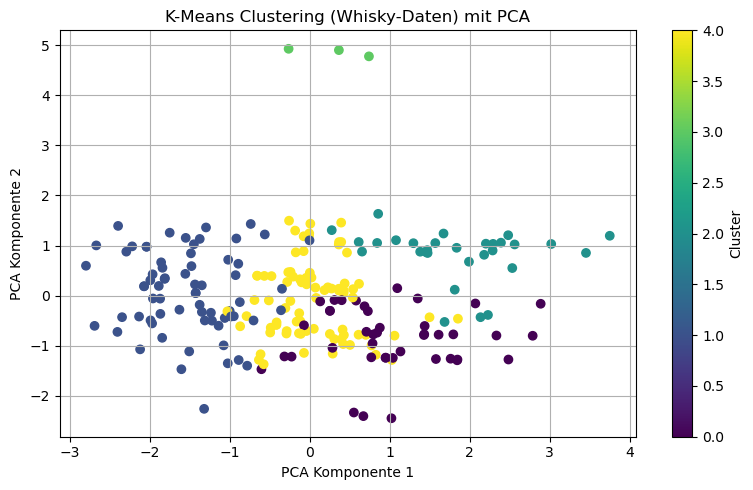

     index  Score  Proof Leather Sweetness  Nose_cat  cluster
0        0     59    100       0         3         2        2
1        1     65     86       6         0         2        2
2        2     65     93       5         0         2        2
3        3     65    101       0         0         1        4
4        4     70    100       3         0         1        2
..     ...    ...    ...     ...       ...       ...      ...
219    219     95     90       0         2         1        1
220    220     95     86       0         4         1        1
221    221     95    119       0         4         1        1
222    222     95     95       3         4         2        1
223    223     96    119       1         3         1        1

[224 rows x 7 columns]


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Annahme: whisky ist bereits vorhanden, z. B. per CSV geladen
# whisky = pd.read_csv("deine_datei.csv")

# Relevante numerische Features auswählen (ohne Index und Cluster)
features = ['Score', 'Proof', 'Leather', 'Sweetness', 'Nose_cat']
X = whisky[features]

# 1. Standardisierung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# 3. Cluster-Labels hinzufügen
whisky['cluster'] = kmeans.labels_

# 4. PCA zur 2D-Visualisierung
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Visualisierung
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=whisky['cluster'], cmap='viridis')
plt.title('K-Means Clustering (Whisky-Daten) mit PCA')
plt.xlabel('PCA Komponente 1')
plt.ylabel('PCA Komponente 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: DataFrame anzeigen
print(whisky)

In [21]:
# PCA auf 2D reduziert (bereits berechnet)
X_pca = pca.fit_transform(X_scaled)

# Neue Spalten für die PCA-Koordinaten hinzufügen
whisky['PCA1'] = X_pca[:, 0]
whisky['PCA2'] = X_pca[:, 1]

# Ausgabe der Koordinaten mit Cluster
print(whisky[['PCA1', 'PCA2', 'cluster']])

         PCA1      PCA2  cluster
0    1.473436  0.850379        2
1    3.749239  1.194446        2
2    3.452203  0.851924        2
3    1.852262 -0.462008        4
4    2.227359 -0.387038        2
..        ...       ...      ...
219 -1.553816  0.433857        1
220 -2.291194  0.877247        1
221 -2.402244 -0.725475        1
222 -1.295421  1.360433        1
223 -1.843085 -0.843734        1

[224 rows x 3 columns]


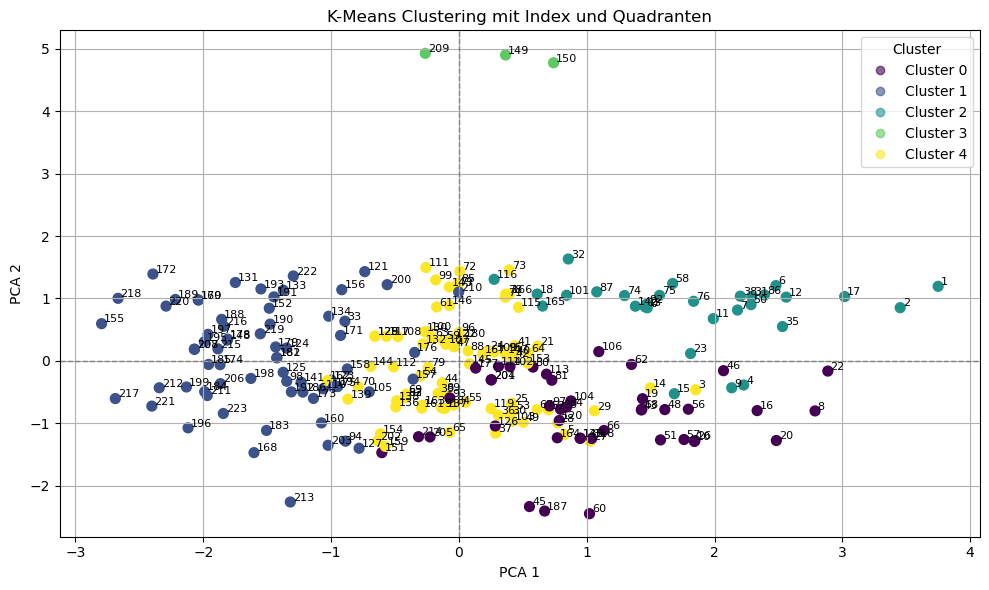

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Cluster-Scatterplot mit Farben
scatter = plt.scatter(
    whisky['PCA1'],
    whisky['PCA2'],
    c=whisky['cluster'],
    cmap='viridis',
    s=50,
    label=whisky['cluster']
)

# 2. Achsenkreuze (für Quadranten)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

# 3. Indizes auf die Punkte schreiben
for i in range(len(whisky)):
    idx = whisky.index[i]
    x = whisky['PCA1'].iloc[i]
    y = whisky['PCA2'].iloc[i]
    plt.text(x + 0.02, y + 0.02, str(idx), fontsize=8, color='black')

# 4. Achsentitel und Legende
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering mit Index und Quadranten')

# 5. Legende erzeugen (eine pro Cluster)
handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)
plt.legend(handles, [f'Cluster {i}' for i in range(len(handles))], title="Cluster")

plt.grid(True)
plt.tight_layout()
plt.show()


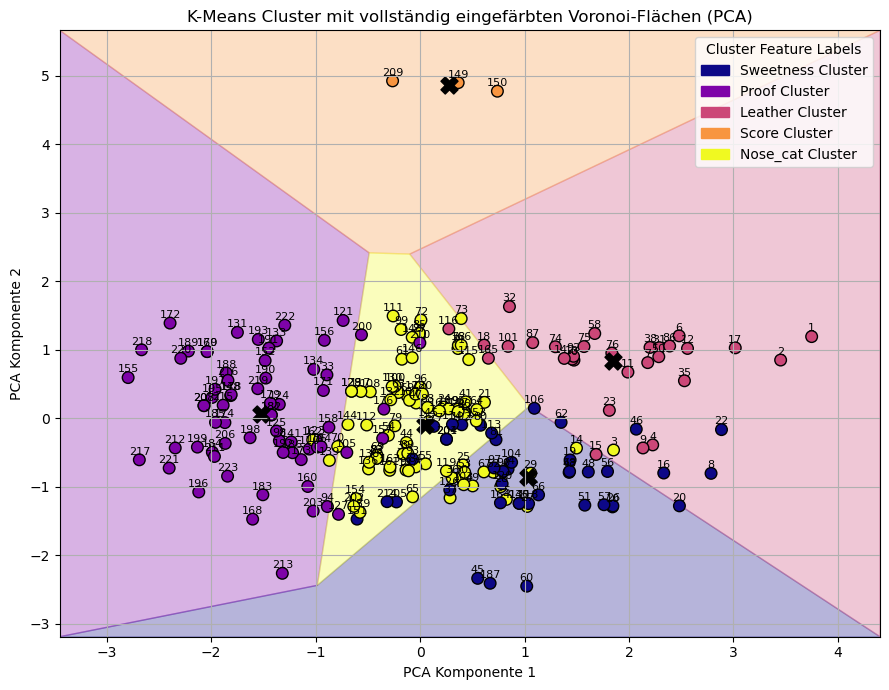

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import Voronoi
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon

cluster_names = {
    0: 'Sweetness Cluster',
    1: 'Proof Cluster',
    2: 'Leather Cluster',
    3: 'Score Cluster',
    4: 'Nose_cat Cluster'
}

colors = plt.cm.plasma(np.linspace(0, 1, 5)) #plt.cm.viridis(np.linspace(0, 1, 5))

# Cluster-Zentren
centers = np.array([X_pca[whisky['cluster'] == i].mean(axis=0) for i in range(5)])

vor = Voronoi(centers)

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite Voronoi regions in a 2D diagram to finite
    polygons clipped to a bounding box.
    Quelle: https://stackoverflow.com/a/20678647
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max()*2

    # Map ridge vertices to all ridges for each point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]
        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0 or v1 < 0:
                # Compute the missing endpoint
                v_finite = v1 if v1 >= 0 else v2
                tangent = vor.points[p2] - vor.points[p1]  # tangent vector
                tangent /= np.linalg.norm(tangent)
                normal = np.array([-tangent[1], tangent[0]])  # normal vector

                midpoint = vor.points[[p1, p2]].mean(axis=0)
                direction = np.sign(np.dot(midpoint - center, normal)) * normal
                far_point = vor.vertices[v_finite] + direction * radius

                new_vertices.append(far_point.tolist())
                new_region.append(len(new_vertices) - 1)

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = [v for _, v in sorted(zip(angles, new_region))]

        new_regions.append(new_region)

    return new_regions, np.asarray(new_vertices)

regions, vertices = voronoi_finite_polygons_2d(vor)

fig, ax = plt.subplots(figsize=(9,7))

# Grenzen für das Plotrechteck (z.B. 5% Rand extra)
margin = 0.1
xmin, xmax = X_pca[:,0].min(), X_pca[:,0].max()
ymin, ymax = X_pca[:,1].min(), X_pca[:,1].max()
dx = xmax - xmin
dy = ymax - ymin
bounds = [xmin - margin*dx, xmax + margin*dx, ymin - margin*dy, ymax + margin*dy]

# Farbige Polygone zeichnen
for region_idx, region in enumerate(regions):
    polygon = vertices[region]
    # Polygon innerhalb der Plotgrenzen clippen
    polygon[:,0] = np.clip(polygon[:,0], bounds[0], bounds[1])
    polygon[:,1] = np.clip(polygon[:,1], bounds[2], bounds[3])

    ax.fill(*zip(*polygon), color=colors[region_idx], alpha=0.3)

# Punkte plotten
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=whisky['cluster'], cmap='plasma', edgecolor='k', s=70) #cmap='viridis'

# Punkte beschriften
for i in range(len(whisky)):
    x = whisky['PCA1'].iloc[i]
    y = whisky['PCA2'].iloc[i]
    idx = whisky.index[i]
    ax.text(x, y + 0.075, str(idx), fontsize=8, color='black', ha='center')
    
# Clusterzentren hervorheben
ax.scatter(centers[:,0], centers[:,1], c='black', s=150, marker='X', label='Cluster Centers')

# Achsen begrenzen
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])

# Legende
patches = [mpatches.Patch(color=colors[i], label=cluster_names[i]) for i in range(5)]
ax.legend(handles=patches, title='Cluster Feature Labels')

ax.set_title('K-Means Cluster mit vollständig eingefärbten Voronoi-Flächen (PCA)')
ax.set_xlabel('PCA Komponente 1')
ax.set_ylabel('PCA Komponente 2')
ax.grid(True)
plt.tight_layout()
plt.show()


In [24]:
whisky2 = whisky2.drop(columns=['Reviewer', 'Nose', 'LeatherDesc', 'SweetDesc'])

In [61]:
input_index = int(input("Enter the index of the whisky you like to see..."))
whisky2.iloc[[input_index]]

Enter the index of the whisky you like to see... 222


,index,Score,Bottle,Proof,Leather,Sweetness,Nose_cat
222,222,95,Black Maple Hill (2013 Original Red Label Wax ...,95,3,4,2
